Acá se optimiza otra función en optuna


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

import sys
from pathlib import Path

sys.path.append(str(Path.cwd().resolve().parent))
from preprocess_vae import load_features

In [2]:
df = load_features()

Filtros de catálogo:
  inicial            : 29575
  maskbits==0        : 27757
  flujo>0 (griz)     : 26166
  profundidad (mag)  : 21340
  SNR>=3 (griz)      : 21287


In [3]:
df.columns

Index(['desi_id', 'mean_fiber_ra', 'mean_fiber_dec', 'z', 'zerr', 'ra', 'dec',
       'type', 'shape_r', 'shape_e1', 'shape_e2', 'sersic', 'ebv', 'brickid',
       'dchisq_psf', 'dchisq_rex', 'dchisq_exp', 'dchisq_dev', 'dchisq_ser',
       'id', 'flux_g', 'flux_r', 'flux_i', 'flux_z', 'flux_w1', 'flux_w2',
       'flux_w3', 'flux_w4', 'flux_ivar_g', 'flux_ivar_r', 'flux_ivar_i',
       'flux_ivar_z', 'flux_ivar_w1', 'flux_ivar_w2', 'flux_ivar_w3',
       'flux_ivar_w4', 'mw_transmission_i', 'fitbits', 'mw_transmission_w1',
       'brickname', 'mw_transmission_z', 'mw_transmission_g', 'maskbits',
       'mw_transmission_w2', 'mw_transmission_w3', 'objid',
       'mw_transmission_w4', 'mw_transmission_r', 'mag_g_corr', 'mag_r_corr',
       'mag_i_corr', 'mag_z_corr', 'SNR_g', 'SNR_r', 'SNR_i', 'SNR_z'],
      dtype='str')

In [4]:
df['mag_w1_corr'] = df['flux_w1']/df['mw_transmission_w1']
df['mag_w2_corr'] = df['flux_w2']/df['mw_transmission_w2']
df['mag_w3_corr'] = df['flux_w3']/df['mw_transmission_w3']
df['mag_w4_corr'] = df['flux_w4']/df['mw_transmission_w4']

In [8]:
df = df[['type', 'shape_r', 'shape_e1', 'shape_e2', 'sersic', "mag_g_corr", "mag_r_corr", "mag_i_corr", "mag_z_corr", "mag_w1_corr", "mag_w2_corr", "mag_w3_corr", "mag_w4_corr",'z']]
df.dropna(inplace=True)
X = df.drop(columns=['z'])
y = df['z']

In [5]:

from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer

from sklearn.metrics import accuracy_score, balanced_accuracy_score, f1_score, classification_report, confusion_matrix
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

In [9]:
def compute_photoz_metrics(z_true, z_pred, threshold=0.05, label=None):
    """Métricas estándar de photo-z: residuos normalizados, sigma_MAD y tasa de outliers catastróficos."""
    z_true = np.asarray(z_true, dtype=float)
    z_pred = np.asarray(z_pred, dtype=float)

    # Residuo normalizado: Δz = (z_pred - z_true) / (1 + z_true)
    delta_z = (z_pred - z_true) / (1 + z_true)

    bias = delta_z.mean()
    std = delta_z.std()
    sigma_mad = 1.4826 * np.median(np.abs(delta_z - np.median(delta_z)))
    eta = (np.abs(delta_z) > threshold).mean() * 100

    if label:
        print(f"--- Métricas photo-z: {label} ---")
    print(f"<Δz> (bias)              = {bias:.5f}")
    print(f"std(Δz)                  = {std:.5f}")
    print(f"σ_MAD                    = {sigma_mad:.5f}")
    print(f"η [%] (|Δz| > {threshold})     = {eta:.3f}")

    return {"delta_z": delta_z, "bias": bias, "std": std, "sigma_mad": sigma_mad, "eta": eta}


def plot_specz_vs_photoz(z_true, z_pred, threshold=0.05, title=None, ax=None):
    """Scatter z_spec vs z_phot con línea 1:1 (punteada) y límites de error catastrófico (rojo, lw=5)."""
    z_true = np.asarray(z_true, dtype=float)
    z_pred = np.asarray(z_pred, dtype=float)

    if ax is None:
        _, ax = plt.subplots(figsize=(8, 8))

    ax.scatter(z_true, z_pred, alpha=0.4, s=4)

    lo = min(z_true.min(), z_pred.min())
    hi = max(z_true.max(), z_pred.max())
    ax.plot([lo, hi], [lo, hi], "k--", lw=2, label="1:1")

    z_line = np.linspace(lo, hi, 200)
    ax.plot(z_line, z_line + threshold * (1 + z_line), color="red", lw=2,
            label=f"Límite error catastrófico (|Δz| > {threshold})")
    ax.plot(z_line, z_line - threshold * (1 + z_line), color="red", lw=2)

    ax.set_xlim(lo, hi)
    ax.set_ylim(lo, hi)
    ax.set_xlabel("Redshift espectroscópico")
    ax.set_ylabel("Redshift fotométrico predicho")
    if title:
        ax.set_title(title)
    ax.legend(loc="upper left", fontsize=8)

    return ax

In [10]:
# Considerando el problema como regresión

X = X.copy()
y = df["z"].copy()

numeric_features = [c for c in X.columns if c != "type"]
categorical_features = ["type"]

preprocessor = ColumnTransformer(
    transformers=[
        ("num", Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler()),
        ]), numeric_features),
        ("cat", Pipeline([
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False)),
        ]), categorical_features),
    ]
)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=124
)

model = Pipeline([
    ("preprocessor", preprocessor),
    ("regressor", RandomForestRegressor(
        n_estimators=200,
        random_state=42,
        max_depth=10,
    ))
])

model.fit(X_train, y_train)
y_pred = model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print(f"MAE:  {mae:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"R2:   {r2:.4f}")

# Residuos normalizados, σ_MAD y η
reg_metrics_v1 = compute_photoz_metrics(y_test.to_numpy(), y_pred, label="Regresión (sin colores)")

MAE:  0.0841
RMSE: 0.1504
R2:   0.8549
--- Métricas photo-z: Regresión (sin colores) ---
<Δz> (bias)              = 0.00719
std(Δz)                  = 0.10147
σ_MAD                    = 0.04639
η [%] (|Δz| > 0.05)     = 31.775


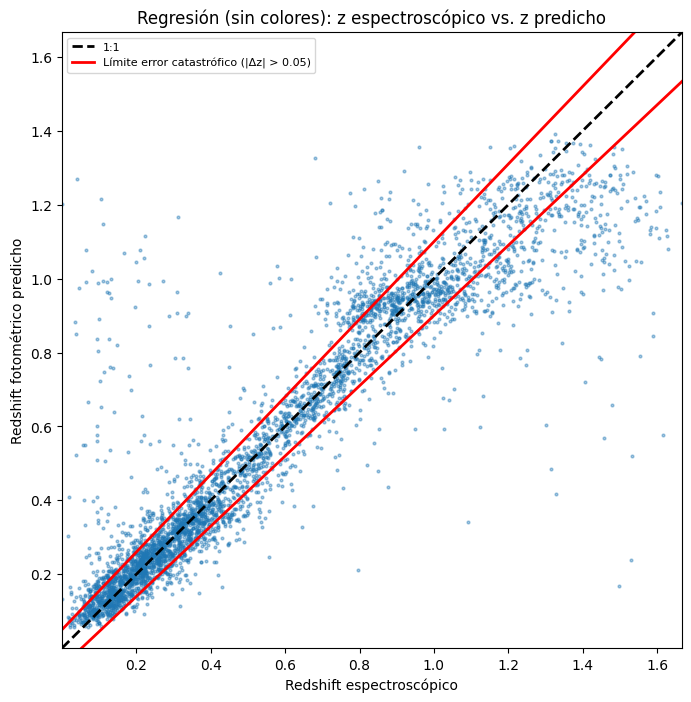

In [11]:
plot_specz_vs_photoz(
    y_test.to_numpy(), y_pred,
    threshold=0.05,
    title="Regresión (sin colores): z espectroscópico vs. z predicho"
)
plt.show()

In [12]:
import optuna
from sklearn.model_selection import train_test_split

# Optimización multiobjetivo con Optuna: σ_MAD y η simultáneamente
# (usa el mismo split X_tr/X_val/y_tr/y_val definido antes)

# Split adicional dentro del train para validación (no tocamos X_test/y_test)
X_tr, X_val, y_tr, y_val = train_test_split(
    X_train, y_train, test_size=0.2, random_state=124
)

def sigma_mad(z_true, z_pred):
    delta_z = (z_pred - z_true) / (1 + z_true)
    return 1.4826 * np.median(np.abs(delta_z - np.median(delta_z)))

def photoz_objectives(z_true, z_pred, threshold=0.05):
    delta_z = (z_pred - z_true) / (1 + z_true)
    s_mad = 1.4826 * np.median(np.abs(delta_z - np.median(delta_z)))
    eta = (np.abs(delta_z) > threshold).mean() * 100
    return s_mad, eta

def objective(trial):
    n_estimators = trial.suggest_int("n_estimators", 100, 500)
    max_depth = trial.suggest_int("max_depth", 3, 30)
    min_samples_split = trial.suggest_int("min_samples_split", 2, 20)
    min_samples_leaf = trial.suggest_int("min_samples_leaf", 1, 20)
    max_features = trial.suggest_categorical("max_features", ["sqrt", "log2", None])

    model = Pipeline([
        ("preprocessor", preprocessor),
        ("regressor", RandomForestRegressor(
            n_estimators=n_estimators,
            max_depth=max_depth,
            min_samples_split=min_samples_split,
            min_samples_leaf=min_samples_leaf,
            max_features=max_features,
            random_state=42,
            n_jobs=-1,
        ))
    ])

    model.fit(X_tr, y_tr)
    y_val_pred = model.predict(X_val)

    s_mad, eta = photoz_objectives(y_val.to_numpy(), y_val_pred)
    return s_mad, eta

study = optuna.create_study(
    directions=["minimize", "minimize"],
    sampler=optuna.samplers.NSGAIISampler(seed=42),
)
study.optimize(objective, n_trials=40, show_progress_bar=True)

print(f"Trials en el frente de Pareto: {len(study.best_trials)}")

# --- Selección de un punto del frente de Pareto ---
# Normalizamos ambos objetivos (0-1) dentro del frente y elegimos el trial
# que minimiza una suma ponderada. Ajusta w_sigma / w_eta según qué te importe más.

pareto_trials = study.best_trials
sigma_vals = np.array([t.values[0] for t in pareto_trials])
eta_vals = np.array([t.values[1] for t in pareto_trials])

sigma_norm = (sigma_vals - sigma_vals.min()) / (sigma_vals.max() - sigma_vals.min() + 1e-12)
eta_norm = (eta_vals - eta_vals.min()) / (eta_vals.max() - eta_vals.min() + 1e-12)

w_sigma, w_eta = 0.5, 0.5  # pesos: súbelos si te importa más una métrica que otra
score = w_sigma * sigma_norm + w_eta * eta_norm

best_idx = np.argmin(score)
best_trial = pareto_trials[best_idx]

print("\nHiperparámetros elegidos del frente de Pareto:")
print(best_trial.params)
print(f"σ_MAD (val) = {sigma_vals[best_idx]:.5f}   η (val) = {eta_vals[best_idx]:.3f}%")

# Vista rápida del frente de Pareto completo
print("\nFrente de Pareto completo (σ_MAD, η):")
for t in sorted(pareto_trials, key=lambda t: t.values[0]):
    print(f"  σ_MAD={t.values[0]:.5f}  η={t.values[1]:.3f}%  params={t.params}")

# --- Entrenamiento final con los hiperparámetros elegidos ---
best_params = best_trial.params

model_pareto = Pipeline([
    ("preprocessor", preprocessor),
    ("regressor", RandomForestRegressor(**best_params, random_state=42, n_jobs=-1))
])

model_pareto.fit(X_train, y_train)
y_pred_pareto = model_pareto.predict(X_test)

mae = mean_absolute_error(y_test, y_pred_pareto)
rmse = np.sqrt(mean_squared_error(y_test, y_pred_pareto))
r2 = r2_score(y_test, y_pred_pareto)

print(f"\nMAE:  {mae:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"R2:   {r2:.4f}")

# Residuos normalizados, σ_MAD y η
reg_metrics_pareto = compute_photoz_metrics(y_test.to_numpy(), y_pred_pareto, label="Regresión optimizada (Pareto σ_MAD/η)")

/home/tamara/hips-env/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
[I 2026-07-01 10:46:13,485] A new study created in memory with name: no-name-828fd720-0352-4bc7-94a1-6aded7422037
  2%|▎         | 1/40 [00:01<00:59,  1.52s/it]

[I 2026-07-01 10:46:15,001] Trial 0 finished with values: [0.04917833787245986, 33.705226071638286] and parameters: {'n_estimators': 250, 'max_depth': 29, 'min_samples_split': 15, 'min_samples_leaf': 12, 'max_features': 'sqrt'}.


  5%|▌         | 2/40 [00:04<01:34,  2.48s/it]

[I 2026-07-01 10:46:18,156] Trial 1 finished with values: [0.0456504411607527, 32.06106870229007] and parameters: {'n_estimators': 447, 'max_depth': 19, 'min_samples_split': 15, 'min_samples_leaf': 1, 'max_features': 'sqrt'}.


  8%|▊         | 3/40 [00:07<01:32,  2.49s/it]

...

[I 2026-07-01 10:48:01,408] Trial 37 finished with values: [0.04656173503368025, 32.853787433940106] and parameters: {'n_estimators': 138, 'max_depth': 20, 'min_samples_split': 20, 'min_samples_leaf': 3, 'max_features': 'log2'}.


 98%|█████████▊| 39/40 [01:54<00:03,  3.37s/it]

[I 2026-07-01 10:48:08,326] Trial 38 finished with values: [0.0409376257216483, 28.978273634762186] and parameters: {'n_estimators': 379, 'max_depth': 22, 'min_samples_split': 8, 'min_samples_leaf': 6, 'max_features': None}.


100%|██████████| 40/40 [02:03<00:00,  3.08s/it]


[I 2026-07-01 10:48:16,737] Trial 39 finished with values: [0.04273630971035023, 30.328831473869645] and parameters: {'n_estimators': 466, 'max_depth': 17, 'min_samples_split': 11, 'min_samples_leaf': 16, 'max_features': None}.
Trials en el frente de Pareto: 1

Hiperparámetros elegidos del frente de Pareto:
{'n_estimators': 116, 'max_depth': 19, 'min_samples_split': 14, 'min_samples_leaf': 1, 'max_features': None}
σ_MAD (val) = 0.04055   η (val) = 28.773%

Frente de Pareto completo (σ_MAD, η):
  σ_MAD=0.04055  η=28.773%  params={'n_estimators': 116, 'max_depth': 19, 'min_samples_split': 14, 'min_samples_leaf': 1, 'max_features': None}

MAE:  0.0791
RMSE: 0.1473
R2:   0.8609
--- Métricas photo-z: Regresión optimizada (Pareto σ_MAD/η) ---
<Δz> (bias)              = 0.00655
std(Δz)                  = 0.09896
σ_MAD                    = 0.04097
η [%] (|Δz| > 0.05)     = 27.666


In [13]:
model_opt = Pipeline([
    ("preprocessor", preprocessor),
    ("regressor", RandomForestRegressor(**best_params, random_state=42, n_jobs=-1))
])

model_opt.fit(X_train, y_train)
y_pred_opt = model_opt.predict(X_test)

mae = mean_absolute_error(y_test, y_pred_opt)
rmse = np.sqrt(mean_squared_error(y_test, y_pred_opt))
r2 = r2_score(y_test, y_pred_opt)

reg_metrics_opt = compute_photoz_metrics(y_test.to_numpy(), y_pred_opt, label="Regresión optimizada (Optuna)")

--- Métricas photo-z: Regresión optimizada (Optuna) ---
<Δz> (bias)              = 0.00655
std(Δz)                  = 0.09896
σ_MAD                    = 0.04097
η [%] (|Δz| > 0.05)     = 27.666


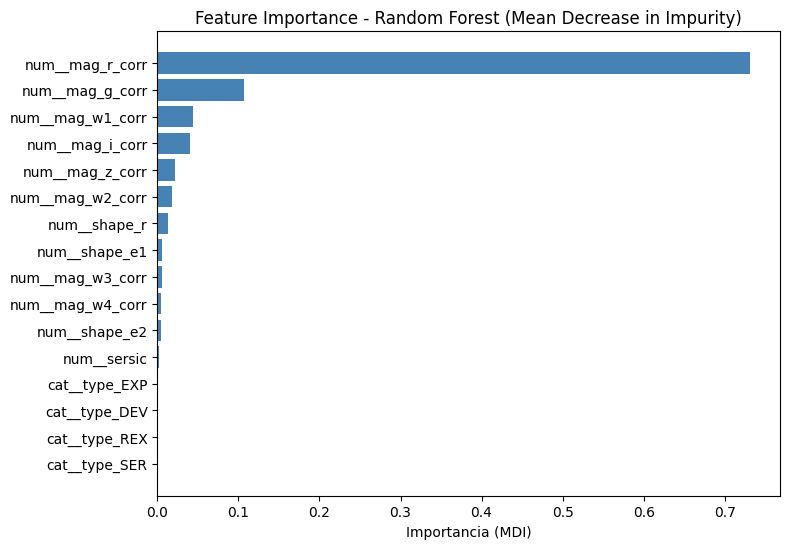

,feature,importance
5,num__mag_r_corr,0.731633
4,num__mag_g_corr,0.106829
8,num__mag_w1_corr,0.043989
6,num__mag_i_corr,0.040223
7,num__mag_z_corr,0.021957
9,num__mag_w2_corr,0.018609
0,num__shape_r,0.012784
1,num__shape_e1,0.005518
10,num__mag_w3_corr,0.005227
11,num__mag_w4_corr,0.005052


In [14]:
# --- Interpretabilidad: Feature Importance (MDI) ---

# Nombres de features tras el preprocesamiento (numéricas + one-hot de "type")
feature_names_out = model_opt.named_steps["preprocessor"].get_feature_names_out()

importances_mdi = model_opt.named_steps["regressor"].feature_importances_

imp_mdi_df = pd.DataFrame({
    "feature": feature_names_out,
    "importance": importances_mdi
}).sort_values("importance", ascending=False)

plt.figure(figsize=(8, max(4, 0.35 * len(imp_mdi_df))))
plt.barh(imp_mdi_df["feature"], imp_mdi_df["importance"], color="steelblue")
plt.gca().invert_yaxis()
plt.xlabel("Importancia (MDI)")
plt.title("Feature Importance - Random Forest (Mean Decrease in Impurity)")
plt.tight_layout()
plt.show()

imp_mdi_df

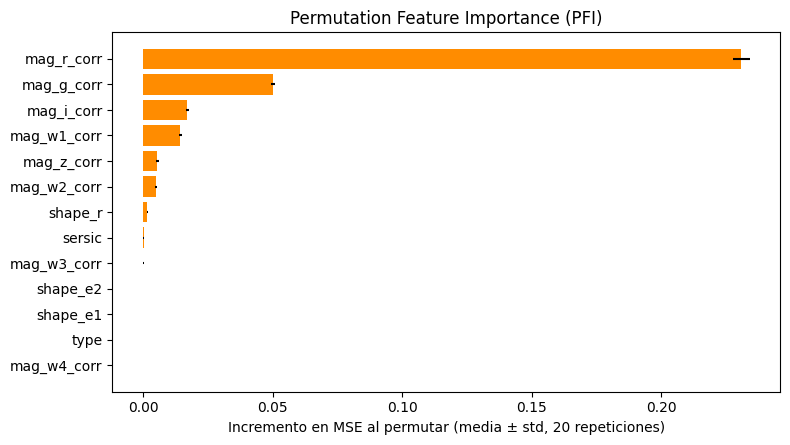

,feature,importance_mean,importance_std
6,mag_r_corr,0.230901,0.003238
5,mag_g_corr,0.050140,0.000873
7,mag_i_corr,0.017169,0.000423
9,mag_w1_corr,0.014338,0.000580
8,mag_z_corr,0.005512,0.000529
10,mag_w2_corr,0.004991,0.000332
1,shape_r,0.001623,0.000229
4,sersic,0.000242,0.000091
11,mag_w3_corr,0.000198,0.000095
3,shape_e2,0.000152,0.000045


In [15]:
# --- Interpretabilidad: Permutation Feature Importance (PFI) ---
from sklearn.inspection import permutation_importance

# Se calcula sobre el pipeline completo (preprocessor + regressor) y el set de test,
# usando neg_mean_squared_error como métrica base (consistente con la optimización)
pfi_result = permutation_importance(
    model_opt,
    X_test,
    y_test,
    scoring="neg_mean_squared_error",
    n_repeats=20,
    random_state=42,
    n_jobs=-1,
)

pfi_df = pd.DataFrame({
    "feature": X_test.columns,  # PFI se calcula sobre features de entrada, no las post-OHE
    "importance_mean": pfi_result.importances_mean,
    "importance_std": pfi_result.importances_std,
}).sort_values("importance_mean", ascending=False)

plt.figure(figsize=(8, max(4, 0.35 * len(pfi_df))))
plt.barh(
    pfi_df["feature"],
    pfi_df["importance_mean"],
    xerr=pfi_df["importance_std"],
    color="darkorange",
)
plt.gca().invert_yaxis()
plt.xlabel("Incremento en MSE al permutar (media ± std, 20 repeticiones)")
plt.title("Permutation Feature Importance (PFI)")
plt.tight_layout()
plt.show()

pfi_df